# Traffic Light Autoencoder - Starter Kit

In [1]:
import os, csv, random, subprocess, sys, zipfile
from pathlib import Path
from functools import lru_cache
from collections import defaultdict
import requests
import os

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode


## Step 1: Download the zip file

This snippet downloads the training dataset ZIP from the course server and saves it locally as training_dataset.zip. 


In [2]:
url = "http://hadi.cs.virginia.edu:9000/download/train-dataset-hw2"
out = Path("training_dataset1.zip")

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with out.open("wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)


## Step 2: Provide the config

In [3]:
# ---------- CONFIG ----------
DATA_ROOT  = Path("data")
ZIP_PATH   = Path("training_dataset.zip")  # provided to students
TRAIN_DIR  = DATA_ROOT / "training_dataset"        # unzip target

IMG_SIZE   = 256 #NOT ALLOWED TO CHANGE
GRAYSCALE  = False
LATENT_DIM = 32
BATCH_SIZE = 64            # drop to 32/16 if OOM
EPOCHS     = 20
LR         = 2e-3
SEED       = 42
MIN_BOX    = 8
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
LAMBDA_L1  = 0.5       # Optional: use mixed loss for sharper recon (0..1) # 0 = pure MSE, 0.5 = half MSE + half L1
random.seed(SEED); torch.manual_seed(SEED)

## Step 3: Unzip the training set

In [4]:

# ---------- Unzip training dataset ----------
def ensure_unzipped(zip_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    # If folder already has images, skip
    has_images = any(p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
                     for p in out_dir.rglob("*"))
    if has_images:
        print(f"Training images already present under: {out_dir}")
        return
    if not zip_path.exists():
        raise SystemExit(f"❗️ Zip not found: {zip_path}\n"
                         f"Place training_dataset.zip at {zip_path} and rerun.")
    print(f"Unzipping {zip_path} -> {out_dir} ...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)
    print("Unzip done.")

ensure_unzipped(ZIP_PATH, TRAIN_DIR)

Unzipping training_dataset.zip -> data/training_dataset ...
Unzip done.


## Optional Step (Please READ)
This zip file was created on MACOS so it may happen that a __MACOSX folder may be created inside data/training_dataset. If it is, please execute below code to delete that folder as it leads 2xthe number of images, which will hamper your performance.

In [5]:
import shutil
import stat

target = Path("data/training_dataset/__MACOSX")

if target.exists():
    if target.is_dir():
        shutil.rmtree(target)
        print(f"Removed: {target}")
    else:
        print(f"Exists but is not a directory: {target}")
else:
    print("Nothing to remove.")

Removed: data/training_dataset/__MACOSX


## Step 4: Collect all training images

In [7]:
# ---------- Collect ALL training images (no labels needed) ----------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
def is_image_file(p: Path) -> bool:
    return p.is_file() and p.suffix.lower() in IMG_EXTS

all_train_imgs = [str(p.resolve()) for p in TRAIN_DIR.rglob("*") if is_image_file(p)]
if not all_train_imgs:
    raise SystemExit(f"No images found under {TRAIN_DIR}. Check your zip contents.")

random.shuffle(all_train_imgs)
n = len(all_train_imgs); n_tr = int(0.9*n)
train_imgs = all_train_imgs[:n_tr]
val_imgs   = all_train_imgs[n_tr:]
print(f"Train/Val (ALL training_dataset/ images): train={len(train_imgs)}  val={len(val_imgs)}")


Train/Val (ALL training_dataset/ images): train=12630  val=1404


## Step 6: Get train_loader and val_loader

In [8]:
# ---------- Transforms / Datasets / Loaders ----------
def fullframe_transform(img_size=IMG_SIZE, grayscale=GRAYSCALE):
    t = [transforms.Resize((img_size, img_size), interpolation=InterpolationMode.BILINEAR)]
    if grayscale: t.append(transforms.Grayscale(1))
    t.append(transforms.ToTensor())  # [0,1]
    return transforms.Compose(t)

FF_TF = fullframe_transform()

class FullFrameDS(Dataset):
    def __init__(self, img_paths): self.paths = img_paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        p = self.paths[i]
        with Image.open(p) as im:
            im = im.convert("RGB")
            x  = FF_TF(im)
        return x, 0

def probe_workers():
    try:
        _ = DataLoader([0], num_workers=2); return 2
    except Exception:
        return 0

nw = probe_workers()
train_loader = DataLoader(FullFrameDS(train_imgs), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=nw, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(FullFrameDS(val_imgs),   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=nw, pin_memory=(DEVICE=="cuda"))

## Step 7: Define Autoencoder and evaluation functions

In [9]:
class Enc(nn.Module):
    def __init__(self, in_ch, ld):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,   32, 4, 2, 1), nn.ReLU(True),  # /2
            nn.Conv2d(32,      64, 4, 2, 1), nn.ReLU(True),  # /4
            nn.Conv2d(64,     128, 4, 2, 1), nn.ReLU(True),  # /8
            nn.Conv2d(128,    256, 4, 2, 1), nn.ReLU(True),  # /16
        )
        self.fc = None
        self.ld = ld
        self.shape = None
    def _init_fc(self, h):
        n, c, H, W = h.shape
        self.shape = (c, H, W)
        self.fc = nn.Linear(c * H * W, self.ld).to(h.device)
    def forward(self, x):
        h = self.conv(x)
        if self.fc is None: self._init_fc(h)
        z = self.fc(h.view(h.size(0), -1))
        return z

class Dec(nn.Module):
    def __init__(self, out_ch, ld, img_size=IMG_SIZE):
        super().__init__()
        self._shape = (256, img_size//16, img_size//16)
        self.fc = nn.Linear(ld, int(np.prod(self._shape)))
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(True),  # x2
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.ReLU(True),  # x4
            nn.ConvTranspose2d(64,   32, 4, 2, 1), nn.ReLU(True),  # x8
            nn.ConvTranspose2d(32, out_ch, 4, 2, 1), nn.Sigmoid(), # x16
        )
    def forward(self, z):
        h = self.fc(z)
        c, H, W = self._shape
        h = h.view(z.size(0), c, H, W)
        return self.deconv(h)

class AE(nn.Module):
    def __init__(self, c, ld, img_size=IMG_SIZE):
        super().__init__()
        self.enc = Enc(c, ld)
        self.dec = Dec(c, ld, img_size)
    def forward(self, x):
        return self.dec(self.enc(x))

CHANNELS = 1 if GRAYSCALE else 3
model = AE(CHANNELS, LATENT_DIM, IMG_SIZE).to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=LR)
crit_mse = nn.MSELoss()
crit_l1  = nn.L1Loss()

def recon_loss(y, x):
    if LAMBDA_L1 <= 0: return crit_mse(y, x)
    return (1 - LAMBDA_L1) * crit_mse(y, x) + LAMBDA_L1 * crit_l1(y, x)

@torch.no_grad()
def eval_full_mse(model, loader):
    model.eval()
    total, n = 0.0, 0
    for x, _ in loader:
        x = x.to(DEVICE)
        y = model(x)
        total += crit_mse(y, x).item() * x.size(0)
        n += x.size(0)
    return total / max(1, n)

best_val = float("inf")
ckpt_path = "model_ts.pt"



## Step 8: Train the model

In [6]:
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
scaler = torch.amp.GradScaler(enabled=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

for ep in range(1, EPOCHS + 1):
    model.train()
    total, n = 0.0, 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        y = model(x)
        loss = recon_loss(y, x)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        scaler.step(opt)
        scaler.update()
        total += loss.item() * x.size(0)
        n     += x.size(0)
    train_loss = total / max(1, n)

    val_mse = eval_full_mse(model, val_loader) if len(val_imgs) else float("nan")
    print(f"epoch {ep:02d} | train_recon {train_loss:.6f} | val_full_mse {val_mse:.6f}")
    if len(val_imgs) and val_mse < best_val:
        best_val = val_mse
        scripted_model = torch.jit.script(model)
        scripted_model.save(ckpt_path)
        print(f"💾 saved {ckpt_path} (best full-image val MSE)")
    scheduler.step()
    
if not Path(ckpt_path).exists():
    scripted_model = torch.jit.script(model)
    scripted_model.save(ckpt_path)
    print(f"💾 saved {ckpt_path} (final TorchScript)")

size_bytes = os.path.getsize(ckpt_path)
size_mb = size_bytes / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

epoch 01 | train_recon 0.093060 | val_full_mse 0.025334
💾 saved model_ts.pt (best full-image val MSE)
Model size: 7.05 MB


## Step 9: Check Error on training dataset provided

In [10]:
all_train_loader = DataLoader(
    FullFrameDS(train_imgs + val_imgs),  # entire training_dataset/
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=nw,
    pin_memory=(DEVICE=="cuda"),
)

In [14]:
model = torch.jit.load("model_v2_mimic.pt", map_location="cuda")
model.eval()
all_full_mse   = eval_full_mse(model, all_train_loader)


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__.py", line 12, in forward
    dec = self.dec
    enc = self.enc
    return (dec).forward((enc).forward(x, ), )
                          ~~~~~~~~~~~~ <--- HERE
class Enc(Module):
  __parameters__ = []
  File "code/__torch__.py", line 25, in forward
    x: Tensor) -> Tensor:
    conv = self.conv
    h = (conv).forward(x, )
         ~~~~~~~~~~~~~ <--- HERE
    fc = self.fc
    _0 = torch.view(h, [torch.size(h, 0), -1])
  File "code/__torch__/torch/nn/modules/container.py", line 38, in forward
    _13 = getattr(self, "13")
    _14 = getattr(self, "14")
    input0 = (_0).forward(input, )
              ~~~~~~~~~~~ <--- HERE
    input1 = (_1).forward(input0, )
    input2 = (_2).forward(input1, )
  File "code/__torch__/torch/nn/modules/conv.py", line 23, in forward
    weight = self.weight
    bias = self.bias
    _0 = (self)._co

In [138]:
print("\n=== Full-image MSE on training data ===")
print(f"Entire training_dataset: {all_full_mse:.6f}")




=== Full-image MSE on training data ===
Entire training_dataset: 0.000176


# Outputs

64


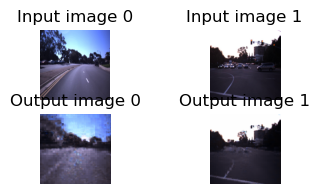

In [204]:
import random
import matplotlib.pyplot as plt


model.eval()
dataiter = iter(val_loader)
images, a = next(dataiter)
print(len(images))


fig, axes = plt.subplots(2, 2, figsize=(4, 2))


# Generate Predicitons
i = images.to(DEVICE)
preds = model(i)[34:36]
preds = preds.cpu()

images = images[34:36]
images = images.cpu()

# Display inputs
for i in range(2):
    img = images[i].permute(1, 2, 0).numpy()  # convert from (C,H,W) to (H,W,C)
    axes[0, i].set_title(f"Input image {i}")
    axes[0, i].imshow(img)
    axes[0, i].axis("off")

# Display predictions
for i in range(2):
    img = preds[i].permute(1, 2, 0).detach().numpy()
    axes[1, i].set_title(f"Output image {i}")
    axes[1, i].imshow(img)
    axes[1, i].axis("off")

plt.show()

## Step 10: Submit to Server and Also Check status

In [13]:
# -------------------------
# Submit to server
# -------------------------
import requests
def submit_model(token: str, model_path: str, server_url="http://hadi.cs.virginia.edu:9000"):
    with open(model_path, "rb") as f:
        files = {"file": f}
        data = {"token": token}
        response = requests.post(f"{server_url}/submit", data=data, files=files)
        resp_json = response.json()
        if "message" in resp_json:
            print(f"✅ {resp_json['message']}")
        else:
            print(f"❌ Submission failed: {resp_json.get('error')}")

my_token="79df3806ff358c68486be939f8bd2196"
submit_model(my_token, "model_v2_mimic_fp32.pt")

✅ Submission received for team 'nomz'. Attempt #38.


In [7]:
# -------------------------
#  Check status
# -------------------------
import requests
import time

def check_submission_status(my_token, max_retries=3):
    url = f"http://hadi.cs.virginia.edu:9000/submission-status/{my_token}"

    for attempt in range(max_retries):
        response = requests.get(url)

        if response.status_code == 200:
            attempts = response.json()
            for a in attempts:
                model_size = f"{a['model_size']:.4f}" if isinstance(a['model_size'], (float, int)) else "None"

                print(f"Attempt {a['attempt']}: Model size={model_size}, "
                      f"Submitted at={a['submitted_at']}, Status={a['status']}")

            if attempts and attempts[-1]['status'].lower() == "broken file":
                print("⚠️ Your model on the server is broken!")
            return  # success, exit function

        elif response.status_code == 429:
            # Server says rate limit exceeded
            try:
                error_json = response.json()
                wait_seconds = int(error_json.get("error", "").split()[-2])
            except Exception:
                wait_seconds = 15  # default fallback
            print(f"⏳ Rate limited. Waiting {wait_seconds} seconds before retry...")
            time.sleep(wait_seconds + 1)  # wait a bit longer to be safe

        else:
            print(f"❌ Error {response.status_code}: {response.text}")
            return

    print("⚠️ Max retries reached. Try again later.")


# Example usage:


check_submission_status("79df3806ff358c68486be939f8bd2196")



Attempt 1: Model size=13.8074, Submitted at=Nov 12, 2025 10:46:41 AM, Status=successful
Attempt 2: Model size=13.8074, Submitted at=Nov 13, 2025 11:22:14 AM, Status=successful
Attempt 3: Model size=12.0573, Submitted at=Nov 16, 2025 04:22:10 PM, Status=successful
Attempt 4: Model size=12.0573, Submitted at=Nov 16, 2025 08:01:23 PM, Status=successful
Attempt 5: Model size=12.0573, Submitted at=Nov 17, 2025 06:14:22 PM, Status=successful
Attempt 6: Model size=11.8385, Submitted at=Nov 18, 2025 12:26:20 AM, Status=successful
Attempt 7: Model size=15.4277, Submitted at=Nov 18, 2025 09:14:13 AM, Status=successful
Attempt 8: Model size=15.4295, Submitted at=Nov 18, 2025 10:30:57 AM, Status=successful
Attempt 9: Model size=15.4277, Submitted at=Nov 18, 2025 02:18:09 PM, Status=successful
Attempt 10: Model size=14.4263, Submitted at=Nov 18, 2025 09:12:18 PM, Status=successful
Attempt 11: Model size=13.8074, Submitted at=Nov 19, 2025 08:41:31 AM, Status=successful
Attempt 12: Model size=14.4263

In [3]:
model = torch.jit.load("model_v2_mimic.pt", map_location="cuda")


In [2]:
import torch

In [4]:
model.eval()


RecursiveScriptModule(
  original_name=Enc
  (conv): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=BatchNorm2d)
    (2): RecursiveScriptModule(original_name=ReLU)
    (3): RecursiveScriptModule(original_name=Conv2d)
    (4): RecursiveScriptModule(original_name=BatchNorm2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=BatchNorm2d)
    (8): RecursiveScriptModule(original_name=ReLU)
    (9): RecursiveScriptModule(original_name=Conv2d)
    (10): RecursiveScriptModule(original_name=BatchNorm2d)
    (11): RecursiveScriptModule(original_name=ReLU)
    (12): RecursiveScriptModule(original_name=Conv2d)
    (13): RecursiveScriptModule(original_name=BatchNorm2d)
    (14): RecursiveScriptModule(original_name=ReLU)
  )
  (fc): RecursiveScriptModule(original_name=Linear)
)

In [5]:
model.dec

RecursiveScriptModule(
  original_name=Dec
  (fc): RecursiveScriptModule(original_name=Linear)
  (deconv): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=BatchNorm2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=ConvTranspose2d)
    (3): RecursiveScriptModule(original_name=BatchNorm2d)
    (4): RecursiveScriptModule(original_name=ReLU)
    (5): RecursiveScriptModule(original_name=ConvTranspose2d)
    (6): RecursiveScriptModule(original_name=BatchNorm2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=ConvTranspose2d)
    (9): RecursiveScriptModule(original_name=BatchNorm2d)
    (10): RecursiveScriptModule(original_name=ReLU)
    (11): RecursiveScriptModule(original_name=ConvTranspose2d)
    (12): RecursiveScriptModule(original_name=BatchNorm2d)
    (13): RecursiveScriptModule(original_name=ReLU)
    (14): RecursiveScriptModule(original_nam

In [22]:
model.eval()
z=model.enc(all_train_loader)

TypeError: conv2d() received an invalid combination of arguments - got (DataLoader, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!DataLoader!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!DataLoader!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [11]:
model = torch.jit.load("model_v2_mimic.pt", map_location="cuda")
model.eval()

batch = next(iter(all_train_loader))
x = batch[0] if isinstance(batch, (tuple, list)) else batch
x = x.to("cuda")

z = model.enc(x)
print(type(z), getattr(z, "shape", None), getattr(z, "dim", lambda: None)())


RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__.py", line 25, in forward
    x: Tensor) -> Tensor:
    conv = self.conv
    h = (conv).forward(x, )
         ~~~~~~~~~~~~~ <--- HERE
    fc = self.fc
    _0 = torch.view(h, [torch.size(h, 0), -1])
  File "code/__torch__/torch/nn/modules/container.py", line 38, in forward
    _13 = getattr(self, "13")
    _14 = getattr(self, "14")
    input0 = (_0).forward(input, )
              ~~~~~~~~~~~ <--- HERE
    input1 = (_1).forward(input0, )
    input2 = (_2).forward(input1, )
  File "code/__torch__/torch/nn/modules/conv.py", line 23, in forward
    weight = self.weight
    bias = self.bias
    _0 = (self)._conv_forward(input, weight, bias, )
          ~~~~~~~~~~~~~~~~~~~ <--- HERE
    return _0
  def _conv_forward(self: __torch__.torch.nn.modules.conv.Conv2d,
  File "code/__torch__/torch/nn/modules/conv.py", line 29, in _conv_f

In [17]:
import torch
from torch.utils.data import DataLoader

DEVICE = "cuda"  # or "cpu"

# 1. Load the student's TorchScript model
model = torch.jit.load("model_v2_mimic.pt", map_location=DEVICE)
model.eval()

# 2. Cast all parameters/buffers to float32
# model = model.to(dtype=torch.float32)

# 3. Build the loader (as you already had)
all_train_loader = DataLoader(
    FullFrameDS(train_imgs + val_imgs),
    batch_size=64,
    shuffle=False,
    num_workers=nw,
    pin_memory=(DEVICE == "cuda"),
)

mse = torch.nn.MSELoss(reduction="mean")

@torch.no_grad()
def eval_full_mse_enc_dec(model, loader, device):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch  # handle (x, path) or x
        x = x.to(device, dtype=torch.float16, non_blocking=(device=="cuda"))

        # strict AE path: enc(x) -> dec(z)
        z = model.enc(x)
        if not isinstance(z, torch.Tensor) or z.dim() != 2:
            raise RuntimeError(f"enc(x) must return 2D Tensor, got {type(z)} with dim={getattr(z, 'dim', lambda: 'NA')()}")

        y = model.dec(z)
        if not isinstance(y, torch.Tensor):
            raise RuntimeError(f"dec(z) must return Tensor, got {type(y)}")

        batch_mse = mse(y, x).item()       # average over batch + pixels
        total += batch_mse * x.size(0)     # weight by batch size
        n += x.size(0)

    return total / max(1, n)

full_mse = eval_full_mse_enc_dec(model, all_train_loader, DEVICE)
print("Full MSE (enc→dec path):", full_mse)

# 4. Save fp32 TorchScript model for server submission
torch.jit.save(model, "model_v2_mimic_fp32.pt")
print("Saved fp32 model to model_v2_mimic_fp32.pt")


Full MSE (enc→dec path): 0.1346539055263111
Saved fp32 model to model_v2_mimic_fp32.pt
